In [19]:
%load_ext autoreload
%autoreload 2

In [20]:
import sys

sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils import reconstruct_cartpole_dmcontrol

In [27]:
import torch
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed
# from common.trajectory_controller import TrajectoryController
# from common.activation_patcher import ActivationPatcher

from analysis.utils import load_sweep_metadata, load_data

In [103]:
df_metadata = load_sweep_metadata(
    ["../logs/25-12-09-cartpole_initial_conditions_seeds_models"],
    json_file_name="episode_metadata.json")
df_metadata = df_metadata[df_metadata['checkpoint'] ==
                          'ckpts/cartpole-swingup-3.pt']
df = load_data(df_metadata,
               cart_position=[0],
               episode_file_name="episode_data.pkl")

Dirs in ../logs/25-12-09-cartpole_initial_conditions_seeds_models: 100%|██████████| 825/825 [00:00<00:00, 2458.43it/s]


Found 825 configurations
Found 55 configurations


100%|██████████| 55/55 [00:00<00:00, 352.80it/s]


In [104]:
z = np.concatenate(df['latent_states'].tolist())
actions = np.concatenate(df['actions'].tolist())
observations = np.concatenate(df['observations'].tolist())

z = torch.from_numpy(z).to('cuda')
observations = torch.from_numpy(observations).to('cuda')
actions = torch.from_numpy(actions).to('cuda')
observations.shape, actions.shape, z.shape

(torch.Size([27500, 5]), torch.Size([27500, 1]), torch.Size([27500, 512]))

Linear Dynamics Model Fit:
  MSE: 0.000100
  Mean R²: 0.987474
  R² range: [0.846744, 0.999848]


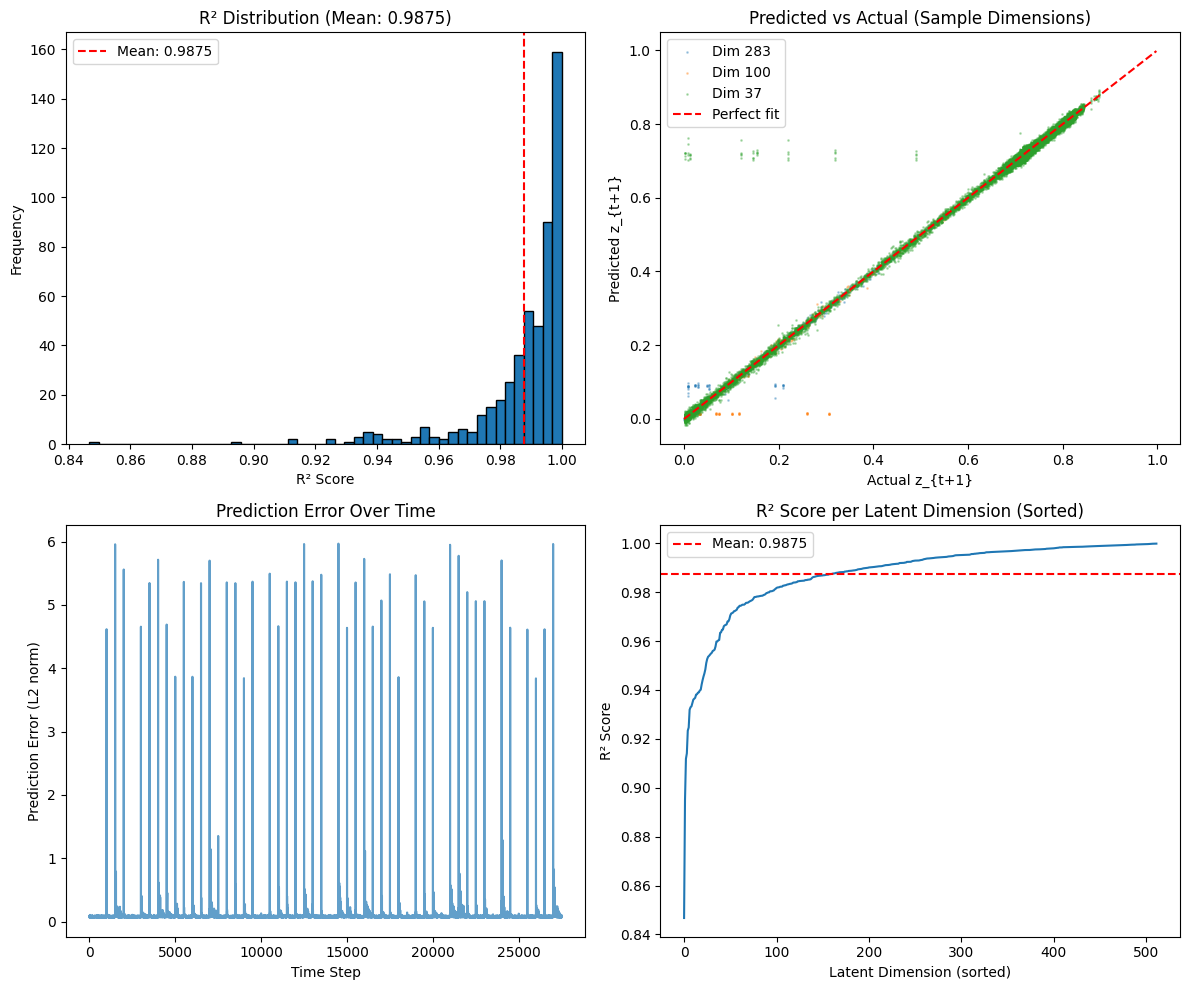


Matrix properties:
  ||A||_F: 694747.9375
  ||B||_F: 0.2018
  A shape: (512, 512)
  B shape: (1, 512)


In [206]:
# Fit linear dynamics model: z_{t+1} = A*z_t + B*a_t
# Prepare data: we need z_t, a_t, and z_{t+1}
z_t = z[:-1]  # Current states
a_t = actions[:-1]  # Actions taken
z_next = z[1:]  # Next states

# Convert to numpy for linear regression
z_t_np = z_t.cpu().numpy()
a_t_np = a_t.cpu().numpy()
z_next_np = z_next.cpu().numpy()

# Concatenate z_t and a_t to form the input matrix X
X = np.concatenate([z_t_np, a_t_np], axis=1)  # Shape: (N, 512+1)

# Solve for [A, B] using least squares: z_{t+1} = [A, B] @ [z_t; a_t]
# X @ W = z_next, where W = [A; B]
W = np.linalg.lstsq(X, z_next_np, rcond=None)[0]  # Shape: (513, 512)

# Split W back into A and B
A = W[:512, :]  # Shape: (512, 512)
B = W[512:, :]  # Shape: (1, 512)

# Compute predictions
z_pred = X @ W  # Shape: (N, 512)

# Compute goodness of fit metrics
mse = np.mean((z_next_np - z_pred)**2)
r2_per_dim = []
for i in range(z_next_np.shape[1]):
    ss_res = np.sum((z_next_np[:, i] - z_pred[:, i])**2)
    ss_tot = np.sum((z_next_np[:, i] - np.mean(z_next_np[:, i]))**2)
    r2 = 1 - (ss_res / ss_tot)
    r2_per_dim.append(r2)
r2_per_dim = np.array(r2_per_dim)
mean_r2 = np.mean(r2_per_dim)

print(f"Linear Dynamics Model Fit:")
print(f"  MSE: {mse:.6f}")
print(f"  Mean R²: {mean_r2:.6f}")
print(f"  R² range: [{np.min(r2_per_dim):.6f}, {np.max(r2_per_dim):.6f}]")

# Visualize goodness of fit
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: R² distribution across latent dimensions
axes[0, 0].hist(r2_per_dim, bins=50, edgecolor='black')
axes[0, 0].set_xlabel('R² Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'R² Distribution (Mean: {mean_r2:.4f})')
axes[0, 0].axvline(mean_r2,
                   color='red',
                   linestyle='--',
                   label=f'Mean: {mean_r2:.4f}')
axes[0, 0].legend()

# Plot 2: Predicted vs Actual for a few random dimensions
sample_dims = np.random.choice(z_next_np.shape[1], size=3, replace=False)
for dim in sample_dims:
    axes[0, 1].scatter(z_next_np[:, dim],
                       z_pred[:, dim],
                       alpha=0.3,
                       s=1,
                       label=f'Dim {dim}')
axes[0, 1].plot([z_next_np.min(), z_next_np.max()],
                [z_next_np.min(), z_next_np.max()],
                'r--',
                label='Perfect fit')
axes[0, 1].set_xlabel('Actual z_{t+1}')
axes[0, 1].set_ylabel('Predicted z_{t+1}')
axes[0, 1].set_title('Predicted vs Actual (Sample Dimensions)')
axes[0, 1].legend()

# Plot 3: Prediction error over time
prediction_error = np.linalg.norm(z_next_np - z_pred, axis=1)
axes[1, 0].plot(prediction_error, alpha=0.7)
axes[1, 0].set_xlabel('Time Step')
axes[1, 0].set_ylabel('Prediction Error (L2 norm)')
axes[1, 0].set_title('Prediction Error Over Time')

# Plot 4: R² per dimension (sorted)
sorted_r2 = np.sort(r2_per_dim)
axes[1, 1].plot(sorted_r2)
axes[1, 1].set_xlabel('Latent Dimension (sorted)')
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].set_title('R² Score per Latent Dimension (Sorted)')
axes[1, 1].axhline(mean_r2,
                   color='red',
                   linestyle='--',
                   label=f'Mean: {mean_r2:.4f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print matrix norms for A and B
print(f"\nMatrix properties:")
print(f"  ||A||_F: {np.linalg.norm(A, 'fro'):.4f}")
print(f"  ||B||_F: {np.linalg.norm(B, 'fro'):.4f}")
print(f"  A shape: {A.shape}")
print(f"  B shape: {B.shape}")


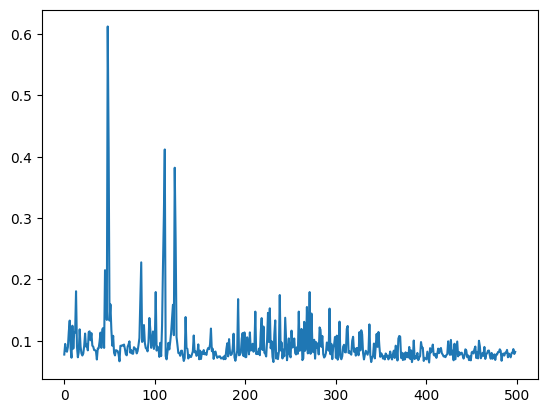

In [209]:
plt.plot(prediction_error[idx_start:idx_end - 1])

In [105]:
# Base configuration
CKPT_PATH = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-3.pt'
override_cfg = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,  # Disable video to speed up sweep
    record_planning=False,  # Focus on episode data
)

with initialize(config_path="../tdmpc2", version_base=None):
    cfg = compose(config_name="config")
    OmegaConf.set_struct(cfg, False)
    cfg = OmegaConf.merge(cfg, override_cfg)

# Parse config
cfg = parse_cfg(cfg)
set_seed(cfg.seed)

cfg.initial_state = {
    'qpos': {
        'slider': 0,  #cart position
        'hinge_1': 0,  # pole angle
    },
}

env = make_env(cfg)

print("\nLoading agent...")
agent = TDMPC2(cfg)

# Optionally load checkpoint
if hasattr(cfg, 'checkpoint') and cfg.checkpoint:
    print(f"Loading checkpoint: {cfg.checkpoint}")
    agent.load(cfg.checkpoint)


Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-3.pt


## Analysi sof prediciton errors

In [106]:
observations.shape

torch.Size([27500, 5])

In [107]:
mask_stable = observations[:, 1] > 0.99
mask_unstable = ~mask_stable
mask_stable = mask_stable.detach().cpu().numpy()
mask_unstable = mask_unstable.detach().cpu().numpy()

z_stable = z[mask_stable]
actions_stable = actions[mask_stable]
observations_stable = observations[mask_stable]

z_swingup = z[mask_unstable]
actions_swingup = actions[mask_unstable]
observations_swingup = observations[mask_unstable]

len(z_stable), len(z_swingup)

(22932, 4568)

In [226]:
# Function to compute multi-step prediction errors
def compute_multistep_prediction_errors(agent,
                                        z,
                                        actions,
                                        observations,
                                        k=1,
                                        open_loop=True,
                                        randomize_actions=False,
                                        use_linear_model=False,
                                        A=None,
                                        B=None):
    """
    Compute k-step prediction errors.
    
    Args:
        agent: The TDMPC2 agent with the world model
        z: Latent states [T, latent_dim]
        actions: Actions [T, action_dim]
        observations: Observations [T, obs_dim]
        k: Number of steps to predict ahead
        open_loop: If True, use closed-loop rollout (predict from previous prediction).
                   If False, re-encode true observation at each step.
        randomize_actions: If True, use random actions instead of the provided actions (baseline).
    
    Returns:
        prediction_errors: Array of prediction errors [T-k, k] - one error per step
        z_preds: Array of predicted latent states
    """
    prediction_errors = []
    z_preds = []
    for t in tqdm(range(len(z) - k)):
        # Start from z[t] and rollout k steps
        z_pred = z[t]
        z_preds.append(z_pred.detach().cpu().numpy())

        step_errors = []
        for step in range(k):
            # Use random actions if randomize_actions is True
            if randomize_actions:
                action = torch.rand_like(
                    actions[t + step]) * 2 - 1  # Random actions in [-1, 1]
            else:
                action = actions[t + step]

            if use_linear_model:
                z_pred = z_pred.unsqueeze(0) @ A + action.unsqueeze(0) @ B
                z_pred = z_pred.squeeze(0)
            else:
                z_pred = agent.model.next(z_pred, action, task=None)
                z_preds.append(z_pred.detach().cpu().numpy())

            # Compare with actual latent state at t+step+1
            z_target = agent.model.encode(observations[t + step + 1], task=None)
            error = (z_pred - z_target).pow(2).sum(-1)
            step_errors.append(error.item())

            # If not open loop, re-encode the true observation for next prediction
            if open_loop:
                z_pred = z_target

        prediction_errors.append(step_errors)

    return np.array(prediction_errors), np.array(z_preds)


In [228]:
# # Compute prediction errors for k=3 steps ahead
# k = 5
# prediction_errors = compute_multistep_prediction_errors(
#     agent,
#     z,
#     actions,
#     observations,
#     use_linear_model=True,
#     k=k,
#     A=torch.from_numpy(A).to(z.device),
#     B=torch.from_numpy(B).to(z.device))


In [116]:
predictions_errors_stable = prediction_errors[mask_stable[:-k]]
predictions_errors_swingup = prediction_errors[mask_unstable[:-k]]

len(predictions_errors_stable), len(predictions_errors_swingup)


(22929, 4568)

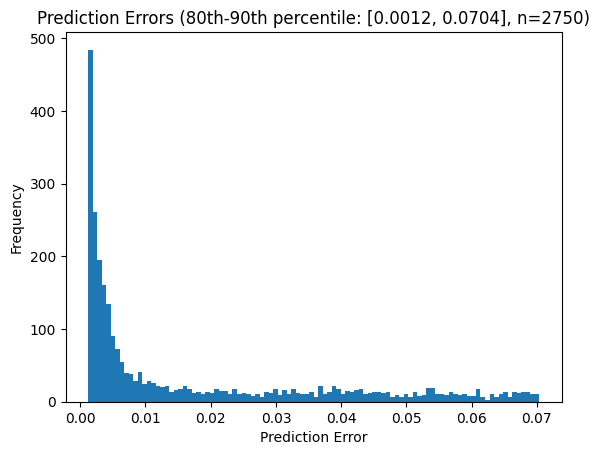

In [117]:
# Filter out first X percentile and last X percentile
lower_percentile = 80  # Remove bottom 10%
upper_percentile = 90  # Remove top 10%

lower_bound = np.percentile(prediction_errors, lower_percentile)
upper_bound = np.percentile(prediction_errors, upper_percentile)
filtered_errors = prediction_errors[(prediction_errors >= lower_bound) &
                                    (prediction_errors <= upper_bound)]

plt.hist(filtered_errors, bins=100)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title(
    f'Prediction Errors ({lower_percentile}th-{upper_percentile}th percentile: [{lower_bound:.4f}, {upper_bound:.4f}], n={len(filtered_errors)})'
)
plt.show()

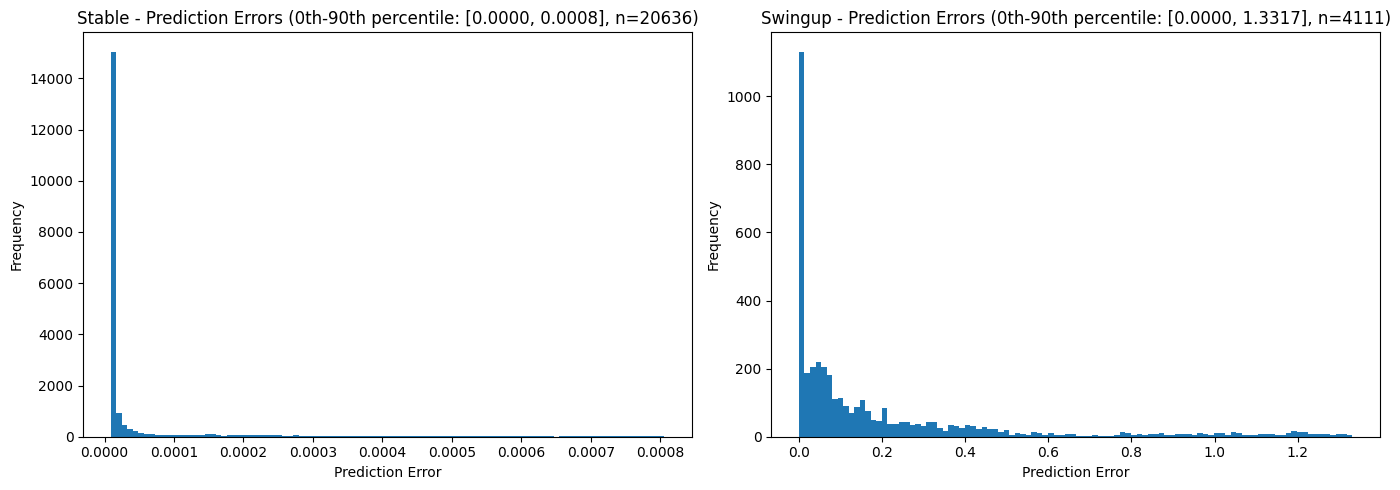

In [118]:
# Filter out first X percentile and last X percentile
lower_percentile = 0  # Remove bottom 10%
upper_percentile = 90  # Remove top 10%

# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Stable errors
lower_bound_stable = np.percentile(predictions_errors_stable, lower_percentile)
upper_bound_stable = np.percentile(predictions_errors_stable, upper_percentile)
filtered_errors_stable = predictions_errors_stable[
    (predictions_errors_stable >= lower_bound_stable) &
    (predictions_errors_stable <= upper_bound_stable)]

ax1.hist(filtered_errors_stable, bins=100)
ax1.set_xlabel('Prediction Error')
ax1.set_ylabel('Frequency')
ax1.set_title(
    f'Stable - Prediction Errors ({lower_percentile}th-{upper_percentile}th percentile: [{lower_bound_stable:.4f}, {upper_bound_stable:.4f}], n={len(filtered_errors_stable)})'
)

# Swingup errors
lower_bound_swingup = np.percentile(predictions_errors_swingup,
                                    lower_percentile)
upper_bound_swingup = np.percentile(predictions_errors_swingup,
                                    upper_percentile)
filtered_errors_swingup = predictions_errors_swingup[
    (predictions_errors_swingup >= lower_bound_swingup) &
    (predictions_errors_swingup <= upper_bound_swingup)]

ax2.hist(filtered_errors_swingup, bins=100)
ax2.set_xlabel('Prediction Error')
ax2.set_ylabel('Frequency')
ax2.set_title(
    f'Swingup - Prediction Errors ({lower_percentile}th-{upper_percentile}th percentile: [{lower_bound_swingup:.4f}, {upper_bound_swingup:.4f}], n={len(filtered_errors_swingup)})'
)

plt.tight_layout()
plt.show()

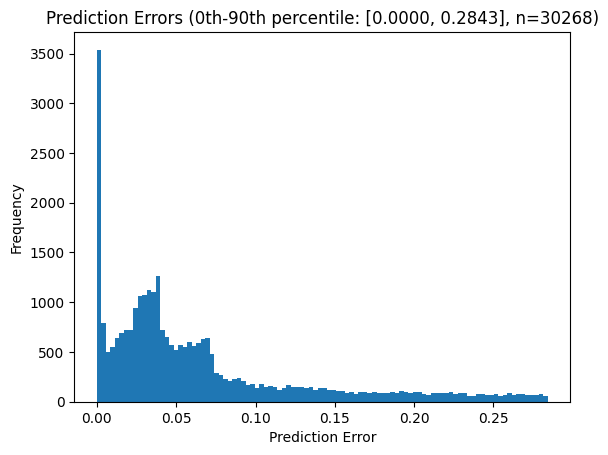

In [101]:
# Filter out first X percentile and last X percentile
lower_percentile = 0  # Remove bottom 10%
upper_percentile = 90  # Remove top 10%

lower_bound = np.percentile(predictions_errors_swingup, lower_percentile)
upper_bound = np.percentile(predictions_errors_swingup, upper_percentile)
filtered_errors = predictions_errors_swingup[
    (predictions_errors_swingup >= lower_bound) &
    (predictions_errors_swingup <= upper_bound)]

plt.hist(filtered_errors, bins=100)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title(
    f'Prediction Errors ({lower_percentile}th-{upper_percentile}th percentile: [{lower_bound:.4f}, {upper_bound:.4f}], n={len(filtered_errors)})'
)
plt.show()

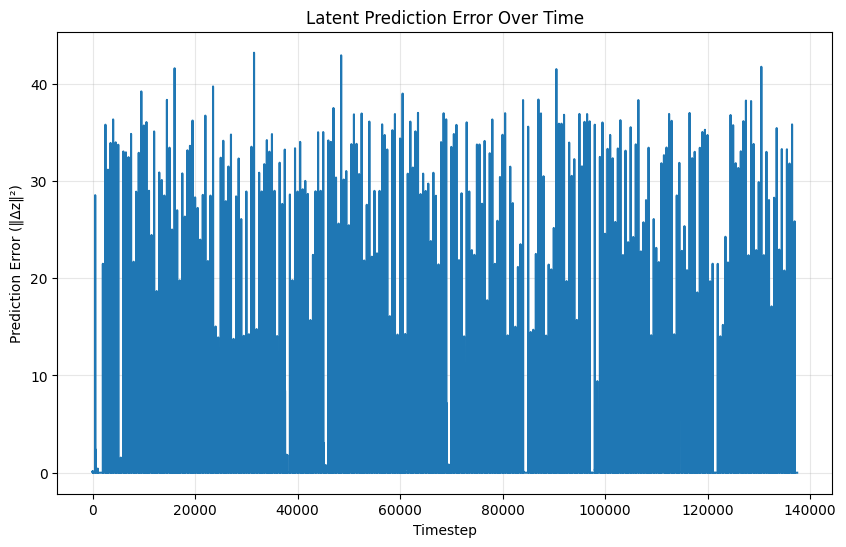

Mean prediction error: 0.0856
Std prediction error: 1.3287
Max prediction error: 43.1738
Min prediction error: 0.0000


In [59]:
# Plot prediction errors
plt.figure(figsize=(10, 6))
plt.plot(prediction_errors)
plt.xlabel('Timestep')
plt.ylabel('Prediction Error (‖Δz‖²)')
plt.title('Latent Prediction Error Over Time')
plt.grid(True, alpha=0.3)
plt.show()

# Summary statistics
print(f"Mean prediction error: {prediction_errors.mean():.4f}")
print(f"Std prediction error: {prediction_errors.std():.4f}")
print(f"Max prediction error: {prediction_errors.max():.4f}")
print(f"Min prediction error: {prediction_errors.min():.4f}")

## Prediction of one episode


In [230]:
episode = 8
idx_start = episode * 500
idx_end = (episode + 1) * 500
z_episode = z[idx_start:idx_end]
actions_episode = actions[idx_start:idx_end]
observations_episode = observations[idx_start:idx_end]

k = 500 - 1
prediction_errors_episode_open_loop, z_preds_episode_open_loop = compute_multistep_prediction_errors(
    agent,
    z_episode,
    actions_episode,
    observations_episode,
    k=k,
    open_loop=True)

prediction_errors_episode_closed_loop, z_preds_episode_closed_loop = compute_multistep_prediction_errors(
    agent,
    z_episode,
    actions_episode,
    observations_episode,
    k=k,
    open_loop=False)

prediction_errors_episode_open_loop_random_actions, z_preds_episode_open_loop_random_actions = compute_multistep_prediction_errors(
    agent,
    z_episode,
    actions_episode,
    observations_episode,
    k=k,
    open_loop=True,
    randomize_actions=True)

prediction_errors_episode_closed_loop_random_actions, z_preds_episode_closed_loop_random_actions = compute_multistep_prediction_errors(
    agent,
    z_episode,
    actions_episode,
    observations_episode,
    k=k,
    open_loop=False,
    randomize_actions=True)

prediction_errors_episode_open_loop_linear_model, z_preds_episode_open_loop_linear_model = compute_multistep_prediction_errors(
    agent,
    z_episode,
    actions_episode,
    observations_episode,
    k=k,
    open_loop=True,
    use_linear_model=True,
    A=torch.from_numpy(A).to(z_episode.device),
    B=torch.from_numpy(B).to(z_episode.device))


100%|██████████| 1/1 [00:00<00:00,  7.24it/s]


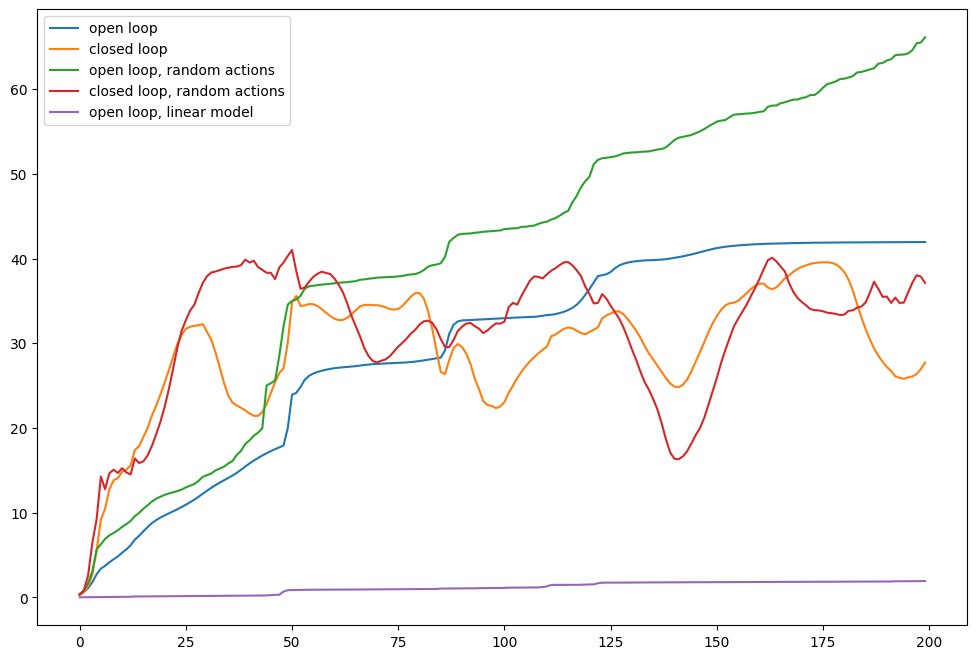

In [235]:
#plt.plot(prediction_errors_episode_open_loop[0, :500])

steps_to_plot = 200
plt.figure(figsize=(12, 8))
plt.plot(np.cumsum(prediction_errors_episode_open_loop[0, :steps_to_plot]),
         label='open loop')
# plt.plot(prediction_errors_episode_open_loop[0, :steps_to_plot],
#          label='open loop, per timestep')
plt.plot(prediction_errors_episode_closed_loop[0, :steps_to_plot],
         label='closed loop')

plt.plot(np.cumsum(
    prediction_errors_episode_open_loop_random_actions[0, :steps_to_plot]),
         label='open loop, random actions')
# plt.plot(prediction_errors_episode_open_loop_random_actions[0, :steps_to_plot],
#          label='random actions, per timestep')

plt.plot(
    prediction_errors_episode_closed_loop_random_actions[0, :steps_to_plot],
    label='closed loop, random actions')

plt.plot(np.cumsum(
    prediction_errors_episode_open_loop_linear_model[0, :steps_to_plot]),
         label='open loop, linear model')

plt.legend()
#plt.plot(np.cumsum(prediction_errors_episode_closed_loop[0, :500]))
# plt.plot(prediction_errors_episode[1, :10])
# plt.plot(prediction_errors_episode[2, :10])
# plt.plot(prediction_errors_episode[3, :10])
# plt.plot(prediction_errors_episode[4, :10])


In [233]:
prediction_errors_episode_open_loop_linear_model

array([[2.14670459e-03, 3.97345098e-03, 1.97262922e-03, 2.74266209e-03,
        3.59688513e-03, 7.94508681e-03, 1.43623007e-02, 1.93386665e-03,
        1.29449763e-03, 9.08253621e-03, 1.51146203e-03, 6.74072187e-03,
        8.82991403e-03, 2.74098404e-02, 3.64306523e-03, 1.21174031e-03,
        1.42898760e-03, 9.84159857e-03, 2.04172637e-03, 1.70011818e-03,
        2.71327095e-03, 2.10387981e-03, 3.97527311e-03, 6.65053912e-03,
        3.88713647e-03, 4.14112862e-03, 2.00610003e-03, 6.33166963e-03,
        7.94897042e-03, 5.21631446e-03, 6.52408553e-03, 4.67710057e-03,
        2.57435022e-03, 1.80916861e-03, 1.95465586e-03, 1.64686807e-03,
        1.21224683e-03, 3.13508278e-03, 4.20012698e-03, 4.89808433e-03,
        6.06318098e-03, 3.94369848e-03, 7.61144189e-03, 9.11724567e-03,
        4.38419916e-03, 3.71123031e-02, 2.88749170e-02, 1.26925586e-02,
        3.73564571e-01, 1.67753994e-01, 1.18697891e-02, 2.19280515e-02,
        8.10004119e-03, 3.55153554e-03, 5.83550520e-03, 1.251088

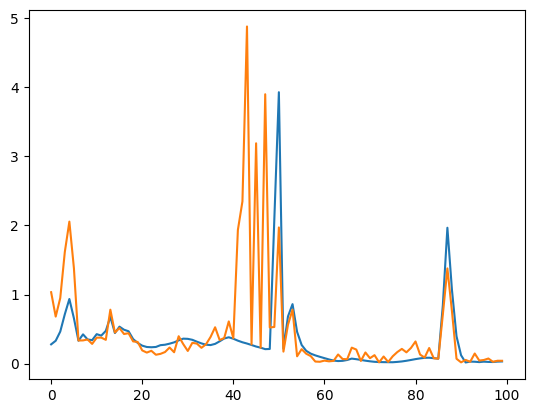

In [205]:
plt.plot(prediction_errors_episode_open_loop[0, :100])
#plt.plot(prediction_errors_episode_closed_loop[0, :100])
plt.plot(prediction_errors_episode_open_loop_random_actions[0, :100])
